In [ ]:
# Works with pytorch - Swin Model
import timm
import pandas as pd
import numpy as np
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
from data_loaders.augmentedMasterTestDataLoader import loadAndSaveData_a

c:\Users\p0prak03\OneDrive - University of Louisville\Desktop\Medical Tool Classification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# load and save data
loadAndSaveData_a(root_dir="D:\\augmented_data_consistent_backgrounds\\images\\train", csvSave="..\\data\\augmenteddata_consistentbackground.csv")

# Load the data into a pandas dataframe [SUCCESSFULLY LOADS ALL IMAGES AND METADATA]
df = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_consistentbackground.csv"))

df

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0
1,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0
2,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0
3,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0
4,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0
...,...,...,...,...,...
2515,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,15.0
2516,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,16.0
2517,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,17.0
2518,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,18.0


In [3]:
instruments = [
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in",
    "Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in", 
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in"
]

state = ["closed", "open"]

# Filter dataset
df_filtered = df[
    (df["instrument"].isin(instruments)) &
    (df["state"].isin(state))
]

# Create label map
label_map = {name: i for i, name in enumerate(instruments)}

# Assign labels
df_filtered["label"] = df_filtered["instrument"].map(label_map)

df_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0,0
1,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0,0
2,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0,0
3,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0,0
4,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0,0
...,...,...,...,...,...,...
2515,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,15.0,2
2516,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,16.0,2
2517,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,17.0,2
2518,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,18.0,2


## TRAIN/VALIDATION SPLIT with TRAINING DATASET

In [4]:
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from data_loaders.InstrumentDataset import InstrumentDataset

In [5]:
df_filtered["group"] = (
    df_filtered["instrument"] + "_" +
    df_filtered["state"] + "_" +
    df_filtered["image_id"].astype(str)
)

# Group-based split
gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_filtered, groups=df_filtered["group"]))

trainDF = df_filtered.iloc[train_idx]
testDF = df_filtered.iloc[test_idx]

In [6]:
# get the instrument data by using the InstrumentDataset class
trainDataset = InstrumentDataset(trainDF)
testDataset = InstrumentDataset(testDF)

# load the data
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True, num_workers=4)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=4)

## Swin Model

In [7]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import os

In [11]:
# check gpu availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Load the pre-trained SWIN-Tiny model
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=len(instruments))

# initialize model in device (preferably GPU)
model = model.to(device)

# ------------------------
# FREEZE BACKBONE
# ------------------------
for param in model.parameters():
    param.requires_grad = False

# Only train classifier head
for param in model.head.parameters():
    param.requires_grad = True


# confirmation
print("MODEL INITIALIZED! BACKBONE FROZEN!")

Using: cuda
MODEL INITIALIZED! BACKBONE FROZEN!


In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4) 
# lower learning rate for SWIN models to warm up
# weight decay stabilizes model

In [14]:
loss_file = "models/AC_Swin_best_loss.txt"

# Load previous best loss if it exists
if os.path.exists(loss_file):
    with open(loss_file, "r") as f:
        bestValLoss = float(f.read())
    print(f"Loaded previous best loss: {bestValLoss}")
else:
    bestValLoss = float('inf')
    print("No previous loss found, starting fresh.")

# TRAINING LOOP
for epoch in range(50):
    # ------------------------
    # UNFREEZE AFTER 5 EPOCHS
    # ------------------------
    if epoch == 5:
        print("Unfreezing entire model...")

        for param in model.parameters():
            param.requires_grad = True

        # reinitialize optimizer for full model
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

    model.train()
    total_loss = 0

    for imgs, labels in trainLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # average training loss (more stable)
    avg_train_loss = total_loss / len(trainLoader)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}")

    # ------------------------
    # VALIDATION LOOP
    # ------------------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in testLoader:   # use real validation set
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # average val loss
    avg_val_loss = val_loss / len(testLoader)
    val_acc = correct / total

    print(f"\tVal Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ------------------------
    # SAVE BEST MODEL (FIXED)
    # ------------------------
    if avg_val_loss < bestValLoss:
        bestValLoss = avg_val_loss

        # save model
        torch.save(model.state_dict(), 'models\\augmentedConsistentBG_Swin_weights.pth')

        # save loss
        with open(loss_file, "w") as f:
            f.write(str(bestValLoss))

        print("\t=> Best Model + Loss Saved!")

No previous loss found, starting fresh.
Epoch 1, Train Loss: 1.1029
	Val Loss: 1.1300 | Val Acc: 0.3174
	=> Best Model + Loss Saved!
Epoch 2, Train Loss: 1.0746
	Val Loss: 1.1069 | Val Acc: 0.3653
	=> Best Model + Loss Saved!
Epoch 3, Train Loss: 1.0535
	Val Loss: 1.0915 | Val Acc: 0.3792
	=> Best Model + Loss Saved!
Epoch 4, Train Loss: 1.0253
	Val Loss: 1.0720 | Val Acc: 0.4032
	=> Best Model + Loss Saved!
Epoch 5, Train Loss: 1.0091
	Val Loss: 1.0547 | Val Acc: 0.4092
	=> Best Model + Loss Saved!
Unfreezing entire model...
Epoch 6, Train Loss: 0.5373
	Val Loss: 0.3710 | Val Acc: 0.8263
	=> Best Model + Loss Saved!
Epoch 7, Train Loss: 0.1208
	Val Loss: 0.4638 | Val Acc: 0.8104
Epoch 8, Train Loss: 0.0377
	Val Loss: 0.5835 | Val Acc: 0.8124
Epoch 9, Train Loss: 0.0213
	Val Loss: 0.6863 | Val Acc: 0.8263
Epoch 10, Train Loss: 0.0269
	Val Loss: 0.4345 | Val Acc: 0.8703
Epoch 11, Train Loss: 0.0897
	Val Loss: 0.4392 | Val Acc: 0.8563
Epoch 12, Train Loss: 0.0159
	Val Loss: 0.5203 | Val 

KeyboardInterrupt: 

In [15]:
# load best weights
model.load_state_dict(torch.load('models\\augmentedConsistentBG_Swin_weights.pth', map_location=device))

# TESTING LOOP
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in testLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 82.63%


## TEST WITH AUGMENTED TESTING DATA

In [16]:
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000019BF55EE660>
Traceback (most recent call last):
  File "c:\Users\p0prak03\OneDrive - University of Louisville\Desktop\Medical Tool Classification\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "c:\Users\p0prak03\OneDrive - University of Louisville\Desktop\Medical Tool Classification\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


In [ ]:
# LOAD VALIDATION (VAL) DATA
loadAndSaveData_a(
    root_dir="D:\\augmented_data_consistent_backgrounds\\images\\val",
    csvSave="..\\data\\augmenteddata_consistentbackground_VAL.csv"
)

df_val = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_consistentbackground_VAL.csv"))

df_val

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN
1,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0
2,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0
3,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0
4,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0
...,...,...,...,...,...
625,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,24,18.0
626,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,NaN
627,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,10.0
628,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,13.0


In [18]:
df_val_filtered = df_val[
    (df_val["instrument"].isin(instruments)) &
    (df_val["state"].isin(state))
]

# use SAME label_map
df_val_filtered["label"] = df_val_filtered["instrument"].map(label_map)

df_val_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN,0
1,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0,0
2,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0,0
3,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0,0
4,D:\augmented_data_consistent_backgrounds\image...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0,0
...,...,...,...,...,...,...
625,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,24,18.0,2
626,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,NaN,2
627,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,10.0,2
628,D:\augmented_data_consistent_backgrounds\image...,Sponge Holding Forceps Foerster Straight Serra...,open,25,13.0,2


In [19]:
# create dataset and loader (non-occluded)
valDataset = InstrumentDataset(df_val_filtered, apply_occlusion=False)
valLoader = DataLoader(valDataset, batch_size=32, shuffle=False)

# create dataset and loader (occluded)
valDatasetOccluded = InstrumentDataset(df_val_filtered, apply_occlusion=True)
valLoaderOccluded = DataLoader(valDatasetOccluded, batch_size=32, shuffle=False)

# load model
model.load_state_dict(torch.load('models\\augmentedConsistentBG_Swin_weights.pth', weights_only=True))

<All keys matched successfully>

In [20]:
def evaluate_model(loader, model, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

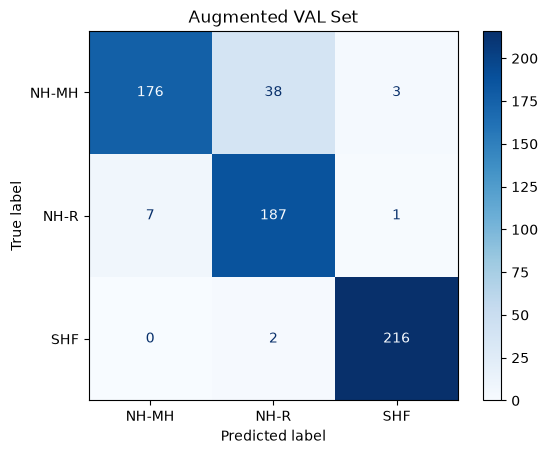

Augmented VAL Accuracy: 91.90%


In [21]:
abbrev_labels = {
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in": "NH-MH",
    "Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in": "NH-R",
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in": "SHF"
}

display_labels = [
    abbrev_labels[name]
    for name in label_map.keys()
]

# Evaluate on augmented VAL set
val_labels, val_preds = evaluate_model(valLoader, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Accuracy: {val_acc * 100:.2f}%")


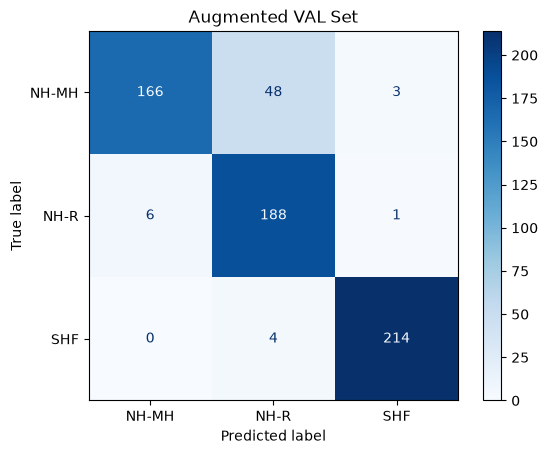

Augmented VAL Occluded Accuracy: 90.16%


In [22]:
# Evaluate on OCCLUDED augmented VAL set
val_labels, val_preds = evaluate_model(valLoaderOccluded, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Occluded Accuracy: {val_acc * 100:.2f}%")